<h3>Heatmaps</h3>
<p>The documentation of the heatmaps with only <code>numpy</code> and <code>matplotlib</code>: <a href = "https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html">Documentation</a></p>

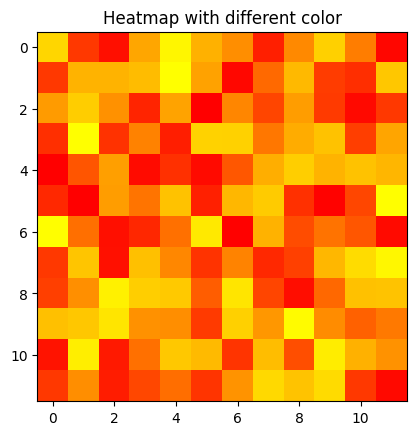

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data = np.random.random((12, 12))
plt.imshow(data, cmap='autumn')

plt.title("Heatmap with different color")
plt.show()


<p>Example more relevant to us. The heatmap for pairwise comparison of the sequences. </p>
<p>I will use <b>Levensthein distance</b> package to calculate how many differences are betweem each pair of sequences</p>
<p><a href = "https://pypi.org/project/python-Levenshtein/">Documentation and installation</a></p>
<p>install with <code>pip install python-Levenshtein</code></p>
<p>seabron heatmap documentation <a href = "https://seaborn.pydata.org/generated/seaborn.heatmap.html">Heatmap documentation</a></p>

In [2]:
from itertools import combinations
import seaborn as sns
from Levenshtein import distance
sequences = ["QLQLVESGGGLVQAGGSLRLSCAASGRTFSSATMGWFRQAPGKEREFVAAISWSGLSRYYADSVKGRFTISRDNAENTVYLQMNSLKTEDTAVYYCAADSWGCSGLGCYDARQYDVWGQGTQVTVSS",
             "QVQLVESGGGLVQPGESLRLSCAASGSIFGIYAVHWFRMAPGKEREFTAGFGSHGSTNYAASVKGRFTMSRDNAKNTTYLQMNSLKPADTAVYYCHALIKNELGFLDYWGPGTQVTVSS",
             "GPHMAQVQLVESGGRLVQAGDSLRLSCAASGRTFSTSAMAWFRQAPGREREFVAAITWTVGNTILGDSVKGRFTISRDRAKNTVDLQMDNLEPEDTAVYYCSARSRGYVLSVLRSVDSYDYWGQGTQVTVS"]

# 1. use numpy to create the empty matrix that wer are going to fill
matrix = np.zeros((3, 3), dtype=int)
# with this small dataset you might be uk with normal loop, but if dataset would be larger the good practise is to use itertools
positions = combinations(list(range(len(sequences))), 2)
res = combinations(sequences, 2)
for (elem1, elem2), (pos1, pos2) in zip(res, positions):
    dist = distance(elem1, elem2)
    matrix[pos2, pos1] = dist 
    matrix[pos1, pos2] = dist

print(matrix)

[[ 0 43 43]
 [43  0 54]
 [43 54  0]]


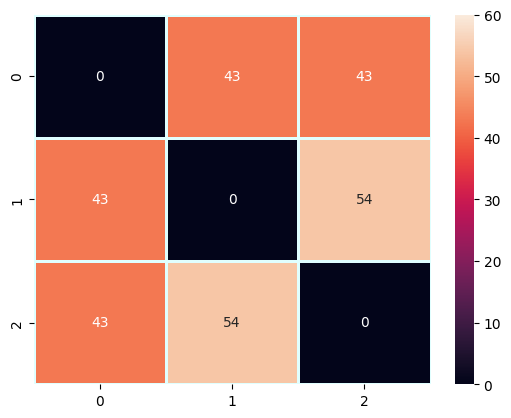

In [3]:
hm = sns.heatmap(data=matrix, annot=True, linewidth=1,
                 linecolor = "#E0FFFF", vmin = 0, vmax = 60)


<ul><li>linewidth - the width of the line that divide the cells</li>
<li>linecolour - the color of the line</li>
<li>annot - Boolean, whether the number is visible or not.</li>
<li>vmin and vmax- dictate the limit of the colour map, you can specify the colour limit that will be higher than any values in your diagram.</li></ul>